#### Importing the basic necessary libraries

In [23]:
import numpy as np # the numpy module is used for numerical operations
import pandas as pd #   the pandas is used for data manipulation and analysis which is in structured format
import matplotlib.pyplot as plt # the matplotlib is used for data visualizations and plotting graphs
import seaborn as sns # the seaborn is used for statistical data visualization built on top of matplotlib

#### Importing the sklearn and its packages for data processing

In [24]:
from sklearn.model_selection import train_test_split # to split the data into training and testing sets in the ratio of 80:20 respectively
from  sklearn.preprocessing import StandardScaler #  to standardize the features by removing the mean and scaling to unit variance

In [25]:
# importing the dataset
dataset = pd.read_csv(r'C:\Users\DELL\OneDrive\Desktop\Celebal_internship\WEEK2\Data\raw\tesla_deliveries_dataset_2015_2025.csv')

In [26]:
df=pd.DataFrame(dataset) # converting the dataset into DataFrame for better data manipulation and analysis
print(df)

      Year  Month         Region       Model  Estimated_Deliveries  \
0     2023      5         Europe     Model S                 17646   
1     2015      2           Asia     Model X                  3797   
2     2019      1  North America     Model X                  8411   
3     2021      2  North America     Model 3                  6555   
4     2016     12    Middle East     Model Y                 12374   
...    ...    ...            ...         ...                   ...   
2635  2021     10    Middle East     Model Y                 13488   
2636  2019      7    Middle East     Model S                 18300   
2637  2019      9           Asia     Model S                 13291   
2638  2020      5           Asia  Cybertruck                  3471   
2639  2018      8  North America     Model S                  2639   

      Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0                17922       92874.27                   120       704   
1            

#### understanding the dataset

In [27]:
#  First 5 rows in the dataset
print(f'First 5 rows in the dataset:\n{df.head()}')
print('~'*50)
print(f'Last 5 rows in the dataset:\n{df.tail()}')
print('~'*50)
rows, columns=df.shape # to get the number of rows and columns in the dataset
print(f'Number of rows = {rows}, Number of columns = {columns}')
print('~'*50)
print(f'Column names in the dataset:\n{df.columns}')
print('~'*50)
print(f'Informatio about the dataset:\n{df.info()}')
print('~'*50)
print(f'Statictical summary of the dataset:\n{df.describe()}')
print('~'*50)

First 5 rows in the dataset:
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)    

In [28]:
#### Features and target variable in the dataset
print(f'Columns in the dataset:\n{df.columns}')

Columns in the dataset:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


In [29]:
# features in the dataset
features = df.drop(columns=['Estimated_Deliveries']) 
print(f'Features in the dataset:\n{features.columns}')
# target variable in the datase
target = df['Estimated_Deliveries']


Features in the dataset:
Index(['Year', 'Month', 'Region', 'Model', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type',
       'Charging_Stations'],
      dtype='object')


In [30]:
# numerical columns in the dataset
numerical_cols= df.select_dtypes(include=['int64', 'float64'])
print(f'Numerical columns in the dataset:\n{numerical_cols.columns}')

Numerical columns in the dataset:
Index(['Year', 'Month', 'Estimated_Deliveries', 'Production_Units',
       'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations'],
      dtype='object')


In [31]:
# categorical columns in the dataset
categorical_cols= df.select_dtypes(include=['object', 'bool'])
print(f'Categorical columns in the dataset:\n{categorical_cols.columns}')

Categorical columns in the dataset:
Index(['Region', 'Model', 'Source_Type'], dtype='object')


- Insight: The Target variable 'Estimated_Deliveries' is a numerical column, which demand to use the regression models

In [32]:
# finding out  the unique values in the categoricaal columns
for col in  categorical_cols.columns:
    unique_values = df[col].unique()
    print(f'Unique values in the columns {col}:\n{unique_values}')
    print('~'*50)

Unique values in the columns Region:
['Europe' 'Asia' 'North America' 'Middle East']
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Unique values in the columns Model:
['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Unique values in the columns Source_Type:
['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [33]:
# missing values
print(f'Missing Values in the dataset:\n{df.isnull().sum()}')
# missing value in percentages
print(f'Missing values in percentage:\n{df.isnull().mean()*100}')

Missing Values in the dataset:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
Missing values in percentage:
Year                    0.0
Month                   0.0
Region                  0.0
Model                   0.0
Estimated_Deliveries    0.0
Production_Units        0.0
Avg_Price_USD           0.0
Battery_Capacity_kWh    0.0
Range_km                0.0
CO2_Saved_tons          0.0
Source_Type             0.0
Charging_Stations       0.0
dtype: float64


- Insight: There are no 'Missing values' in the data

### Data Cleaning/ Data Preprocessing

In [35]:
# handling the missing values
print(f"missing values in the dataset before handling them:\n{df.isnull().sum()}")

missing values in the dataset before handling them:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


- Insight: As there are no missing values there is no need for the process of handing the missing values

In [34]:
# removing the duplicate in the dataset
print(f'Number of duplicate rows in the dataset:\n{df.duplicated().sum()}')

Number of duplicate rows in the dataset:
0


- Insight: As there are no duplicate rows in the dataset there is no need or process of handling them

In [36]:
# to fix the Data types
print((f'Data types before fixing them:\n{df.dtypes}'))

Data types before fixing them:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object


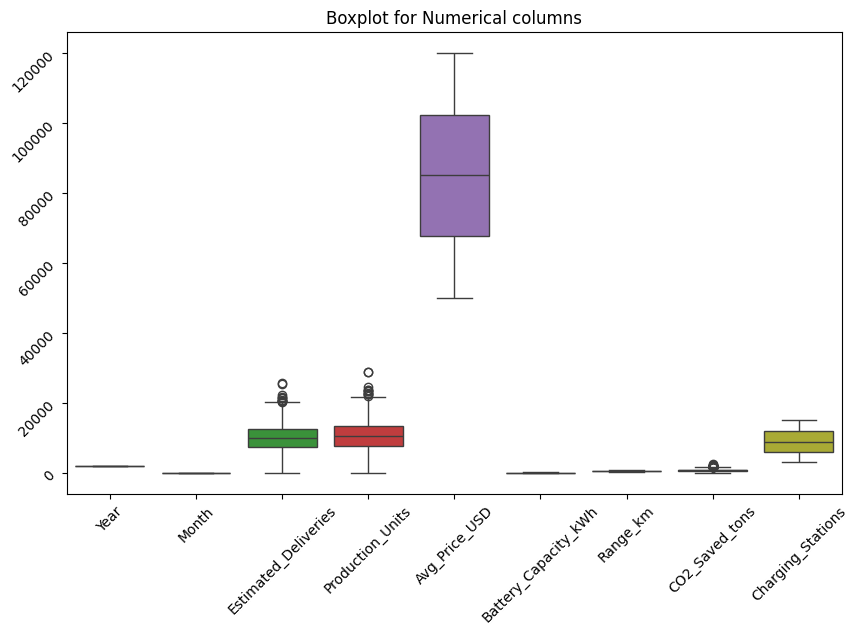

In [37]:
# handling the outliers in the dataset
plt.figure(figsize=(10, 6))
plt.title('Boxplot for Numerical columns')
sns.boxplot(data=df[numerical_cols.columns])
plt.xticks(rotation=45) # to rotate the x-axis labels by  45 degrees for better visibility
plt.yticks(rotation=45) # to rotate the y-axis labels by  45 degrees for better visibility
plt.show()

In [38]:
# represnting the outliers in the dataset in the numerical form
for col in numerical_cols.columns:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[df[col] < lower_bound][col].tolist() + df[df[col] >upper_bound][col].tolist()
    print(f'Outliers in the columns {col}: \n{outliers}')

Outliers in the columns Year: 
[]
Outliers in the columns Month: 
[]
Outliers in the columns Estimated_Deliveries: 
[21296, 20841, 25410, 22315, 21473, 20529, 20358, 25704, 20568, 20577, 20667, 21772]
Outliers in the columns Production_Units: 
[23581, 23735, 28802, 22673, 24427, 22003, 28939, 22879, 22618, 22594, 23519, 23530]
Outliers in the columns Avg_Price_USD: 
[]
Outliers in the columns Battery_Capacity_kWh: 
[]
Outliers in the columns Range_km: 
[]
Outliers in the columns CO2_Saved_tons: 
[1863.42, 1747.18, 1895.3, 1652.87, 1633.34, 1647.1, 1689.91, 1631.17, 1828.46, 1622.32, 1619.03, 1695.5, 1689.4, 1680.74, 1866.22, 1632.2, 2140.15, 1860.48, 1786.37, 1753.25, 2032.73, 1652.61, 1801.68, 1764.8, 2548.55, 1627.85, 1661.15, 1800.64, 2048.57, 1803.45, 1743.07, 1641.8, 1875.08, 1736.64, 1888.55, 1856.23, 1724.87, 2203.8, 2111.23, 1637.36, 1763.84, 1812.84, 1815.57, 1977.5, 1769.61]
Outliers in the columns Charging_Stations: 
[]
